В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [4]:
cars_df = pd.read_csv('cars.csv')

cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [ ]:
# приклад як викликати документацію, якщо у Вас pandas імпортований як pd
?pd.DataFrame.info

In [5]:
cars_df.dtypes

Car_ID                int64
Brand                object
Model                object
Year                  int64
Kilometers_Driven     int64
Fuel_Type            object
Transmission         object
Owner_Type           object
Mileage               int64
Engine                int64
Power                 int64
Seats                 int64
Price                 int64
dtype: object

In [6]:
summary_df = pd.DataFrame({
    'dtype': cars_df.dtypes,
    'actual_types': [
        cars_df[col].map(lambda x: type(x).__name__).unique()
        for col in cars_df.columns
    ],
    'n_unique': cars_df.nunique()
})

summary_df

,dtype,actual_types,n_unique
Car_ID,int64,[int],100
Brand,object,[str],11
Model,object,[str],58
Year,int64,[int],6
Kilometers_Driven,int64,[int],18
Fuel_Type,object,[str],2
Transmission,object,[str],2
Owner_Type,object,[str],3
Mileage,int64,[int],15
Engine,int64,[int],36


In [10]:
categorical_cols = cars_df.select_dtypes(include=['object']).columns

categorical_cols

Index(['Brand', 'Model', 'Fuel_Type', 'Transmission', 'Owner_Type'], dtype='object')

In [11]:
for col in categorical_cols:
    print(col)
    print(cars_df[col].unique())
    print("Кількість унікальних значень:", cars_df[col].nunique())
    print()


Brand
['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes']
Кількість унікальних значень: 11

Model
['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport']
Кількість унікальних значень: 58

Fuel_Type
['Petrol' 'Diesel']
Кількість унікальних значень: 2

Transmission
['Manual' 'Automatic']
Кількість унікальних значень: 2

Owner_Type
['First' 'Second' 'Third']
Кількість унікальних значень: 3



8 числових колонок

5 категоріальних 

Бінарні:
Fuel_Type, Transmission

Мультикатегоріальні без порядку:
Brand, Model

Мультикатегоріальна з порядком:
Owner_Type

В наборі даних є 8 числових колонок і 5 категоріальних колонок. Фактично числові колонки містять значення типу `int`, а категоріальні колонки містять текстові значення типу `str`.

Серед категоріальних колонок є 2 бінарні колонки: `Fuel_Type` і `Transmission`, бо вони мають лише по 2 унікальні значення. Також є 2 мультикатегоріальні колонки без порядку: `Brand` і `Model`, бо вони мають більше ніж 2 значення, але між ними немає логічного порядку. Колонка `Owner_Type` є мультикатегоріальною з порядком, бо значення `First`, `Second`, `Third` можна впорядкувати.

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [12]:
X = cars_df.drop('Price', axis=1)
y = cars_df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=12
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 12), (20, 12), (80,), (20,))

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [13]:
print("Fuel_Type:")
print(X_train['Fuel_Type'].value_counts())

print("\nTransmission:")
print(X_train['Transmission'].value_counts())

Fuel_Type:
Fuel_Type
Petrol    41
Diesel    39
Name: count, dtype: int64

Transmission:
Transmission
Automatic    49
Manual       31
Name: count, dtype: int64


In [14]:
X_train = X_train.copy()
X_test = X_test.copy()

fuel_type_codes = {
    'Petrol': 1,
    'Diesel': 0
}

transmission_codes = {
    'Automatic': 1,
    'Manual': 0
}

X_train['Fuel_Type_code'] = X_train['Fuel_Type'].map(fuel_type_codes)
X_test['Fuel_Type_code'] = X_test['Fuel_Type'].map(fuel_type_codes)

X_train['Transmission_code'] = X_train['Transmission'].map(transmission_codes)
X_test['Transmission_code'] = X_test['Transmission'].map(transmission_codes)

X_train[['Fuel_Type', 'Fuel_Type_code', 'Transmission', 'Transmission_code']].head()

,Fuel_Type,Fuel_Type_code,Transmission,Transmission_code
83,Petrol,1,Automatic,1
55,Diesel,0,Automatic,1
26,Petrol,1,Automatic,1
54,Petrol,1,Manual,0
19,Petrol,1,Automatic,1


In [15]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoder.fit(X_train[['Brand']])

brand_train_encoded = encoder.transform(X_train[['Brand']])
brand_test_encoded = encoder.transform(X_test[['Brand']])

brand_cols = encoder.get_feature_names_out(['Brand'])

brand_train_df = pd.DataFrame(
    brand_train_encoded,
    columns=brand_cols,
    index=X_train.index
)

brand_test_df = pd.DataFrame(
    brand_test_encoded,
    columns=brand_cols,
    index=X_test.index
)

X_train = pd.concat([X_train, brand_train_df], axis=1)
X_test = pd.concat([X_test, brand_test_df], axis=1)

X_train.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,...,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [16]:
owner_encoder = OrdinalEncoder(categories=[['First', 'Second', 'Third']])

owner_encoder.fit(X_train[['Owner_Type']])

X_train['Owner_Type_code'] = owner_encoder.transform(X_train[['Owner_Type']])
X_test['Owner_Type_code'] = owner_encoder.transform(X_test[['Owner_Type']])

X_train[['Owner_Type', 'Owner_Type_code']].head()

,Owner_Type,Owner_Type_code
83,Second,1.0
55,First,0.0
26,First,0.0
54,Second,1.0
19,Second,1.0


In [17]:
from sklearn.preprocessing import OrdinalEncoder

ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [18]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_code,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_code,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [19]:
X_train_numeric = X_train.select_dtypes(include=['int64', 'float64'])

train_corr_df = pd.concat([X_train_numeric, y_train], axis=1)

corr_matrix = train_corr_df.corr()

price_corr = corr_matrix['Price'].drop('Price').sort_values(
    key=lambda x: x.abs(), 
    ascending=False
)

strong_price_corr = price_corr[price_corr.abs() > 0.5]

display(corr_matrix)
display(strong_price_corr)

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_code,Owner_Type_Codes,Price
Car_ID,1.000000,0.137027,-0.356614,0.100891,-0.089284,-0.006319,-0.063793,0.090537,-0.084381,0.089473,0.048335,-0.020240,-0.050809,0.016831,0.006797,-0.054463,-0.045431,-0.032926,0.011350,0.020129,0.038923,0.038923,0.025560
Year,0.137027,1.000000,-0.708525,0.278559,-0.392764,-0.248442,-0.278755,0.248515,-0.200603,-0.256523,0.202517,-0.150454,-0.037437,-0.092099,0.181669,0.285094,-0.115157,0.248715,-0.219346,0.018255,-0.014499,-0.014499,-0.233769
Kilometers_Driven,-0.356614,-0.708525,1.000000,-0.126621,0.101219,-0.060803,0.403656,-0.332351,-0.066491,0.095879,-0.247042,-0.009761,0.057372,0.154362,-0.040344,-0.190420,-0.091731,0.030399,0.368519,-0.137675,-0.001772,-0.001772,-0.083951
Mileage,0.100891,0.278559,-0.126621,1.000000,-0.710516,-0.684705,-0.178619,-0.070112,-0.399164,-0.152701,-0.134105,-0.296480,0.358630,0.217406,0.029427,0.116389,-0.238489,0.347678,-0.201565,0.085114,0.026624,0.026624,-0.638404
Engine,-0.089284,-0.392764,0.101219,-0.710516,1.000000,0.801638,0.167326,-0.174455,0.456296,0.085153,0.287119,0.184231,-0.154491,-0.182213,-0.024973,-0.193257,0.163871,-0.340051,0.234889,-0.165115,-0.196106,-0.196106,0.710561
Power,-0.006319,-0.248442,-0.060803,-0.684705,0.801638,1.000000,-0.139388,0.076357,0.586910,0.157050,0.372652,0.240501,-0.191810,-0.170966,-0.118021,-0.220984,0.280827,-0.316989,-0.040478,-0.148437,-0.204309,-0.204309,0.849137
Seats,-0.063793,-0.278755,0.403656,-0.178619,0.167326,-0.139388,1.000000,-0.412468,-0.070099,0.123674,-0.108079,-0.161451,0.200303,-0.086439,0.007738,-0.078379,-0.108079,-0.012748,0.348535,-0.094002,-0.043849,-0.043849,0.000979
Fuel_Type_code,0.090537,0.248515,-0.332351,-0.070112,-0.174455,0.076357,-0.412468,1.000000,-0.005775,-0.008336,-0.048475,0.109812,-0.161425,-0.007121,-0.235225,0.148511,-0.048475,0.066164,-0.008336,0.125010,0.281122,0.281122,-0.110782
Transmission_code,-0.084381,-0.200603,-0.066491,-0.399164,0.456296,0.586910,-0.070099,-0.005775,1.000000,0.265132,0.283188,-0.122816,-0.218620,0.031659,-0.170703,-0.112622,0.283188,-0.397609,-0.076974,0.155500,0.005886,0.005886,0.680731
Brand_Audi,0.089473,-0.256523,0.095879,-0.152701,0.085153,0.157050,0.123674,-0.008336,0.265132,1.000000,-0.118678,-0.118678,-0.086066,-0.094916,-0.076472,-0.086066,-0.118678,-0.125988,-0.111111,-0.103221,-0.203925,-0.203925,0.328858


Power                0.849137
Engine               0.710561
Transmission_code    0.680731
Mileage             -0.638404
Name: Price, dtype: float64

З цільовою змінною `Price` більше ніж на 0.5 за модулем корелюють колонки `Power`, `Engine`, `Transmission_code` та `Mileage`. `Power`, `Engine` і `Transmission_code` мають позитивну кореляцію з ціною, тобто зі збільшенням цих значень ціна зазвичай зростає. `Mileage` має негативну кореляцію з `Price`, тобто зі збільшенням цього показника ціна автомобіля має тенденцію зменшуватись.


**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [20]:
X_train_numeric = X_train.select_dtypes(include=['number'])
X_test_numeric = X_test.select_dtypes(include=['number'])

In [21]:
X_test_numeric = X_test_numeric[X_train_numeric.columns]


In [22]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_numeric, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
X_train_numeric = X_train.select_dtypes(include=['number'])
X_test_numeric = X_test.select_dtypes(include=['number'])

X_test_numeric = X_test_numeric[X_train_numeric.columns]

lin_reg = LinearRegression()
lin_reg.fit(X_train_numeric, y_train)

y_train_pred = lin_reg.predict(X_train_numeric)
y_test_pred = lin_reg.predict(X_test_numeric)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)

Train RMSE: 210293.57828151883
Test RMSE: 258181.5611203272


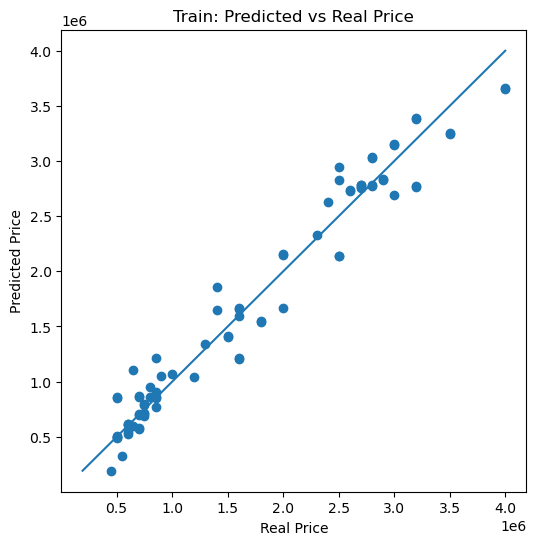

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_train_pred)
plt.xlabel('Real Price')
plt.ylabel('Predicted Price')
plt.title('Train: Predicted vs Real Price')

min_val = min(y_train.min(), y_train_pred.min())
max_val = max(y_train.max(), y_train_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()

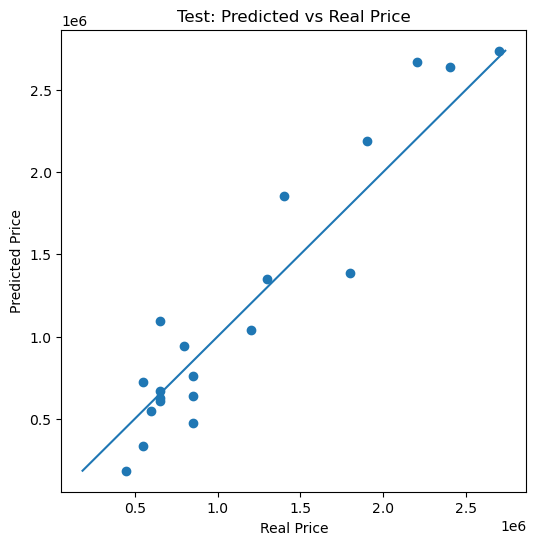

In [26]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred)
plt.xlabel('Real Price')
plt.ylabel('Predicted Price')
plt.title('Test: Predicted vs Real Price')

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()

Після тренування лінійної регресії було отримано `Train RMSE ≈ 210293.58` та `Test RMSE ≈ 258181.56`.

На тренувальних даних модель показує кращий результат, ніж на тестових, що є очікуваним, оскільки модель навчалась саме на `X_train`. На графіку для тренувального набору більшість точок розташовані близько до діагональної лінії, тобто передбачення досить близькі до реальних значень.

На тестовому наборі розкид точок більший, а `Test RMSE` також вищий. Це означає, що модель робить більшу помилку на нових даних, але загальна тенденція передбачень зберігається. Отже, якість моделі можна оцінити як непогану для базової лінійної регресії, але модель не є ідеальною.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [27]:
X_train_numeric = X_train.select_dtypes(include=['number'])
X_test_numeric = X_test.select_dtypes(include=['number'])

In [28]:
X_test_numeric = X_test_numeric[X_train_numeric.columns]

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

In [31]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train_numeric.columns,
    index=X_train_numeric.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test_numeric.columns,
    index=X_test_numeric.index
)

X_train_scaled_df.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Fuel_Type_code,Transmission_code,Brand_Audi,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Mahindra,Brand_Maruti,Brand_Mercedes,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Owner_Type_code,Owner_Type_Codes
83,1.090928,0.568813,-0.693871,0.274862,-0.628491,-0.231967,-0.303562,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,3.229330,0.535303,0.535303
55,0.100381,-0.323442,-0.039533,-0.018324,0.087196,0.247012,-0.303562,-1.025320,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,-0.994135,-0.994135
26,-0.925542,-0.323442,-0.039533,-0.604696,0.111560,0.910213,-0.303562,0.975305,0.795395,3.000000,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,-0.309662,-0.994135,-0.994135
54,0.065005,-1.215697,0.396692,0.274862,-0.476217,-0.784634,-0.303562,0.975305,-1.257237,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,-0.356034,-0.377964,-0.333333,3.229330,0.535303,0.535303
19,-1.173178,-1.215697,-0.257646,-1.484254,0.122219,0.910213,-0.303562,0.975305,0.795395,-0.333333,-0.356034,-0.356034,-0.258199,-0.284747,-0.229416,-0.258199,2.808717,-0.377964,-0.333333,-0.309662,0.535303,0.535303


In [32]:
lin_reg_scaled = LinearRegression()
lin_reg_scaled.fit(X_train_scaled_df, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
coef_df = pd.DataFrame({
    'feature': X_train_scaled_df.columns,
    'coefficient': lin_reg_scaled.coef_
})

coef_df['abs_coefficient'] = coef_df['coefficient'].abs()

coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

coef_df

,feature,coefficient,abs_coefficient
5,Power,496769.214899,496769.214899
16,Brand_Mercedes,210048.781148,210048.781148
10,Brand_BMW,208407.313783,208407.313783
9,Brand_Audi,205600.147769,205600.147769
7,Fuel_Type_code,-183848.018909,183848.018909
13,Brand_Hyundai,-152304.863911,152304.863911
14,Brand_Mahindra,-140945.162904,140945.162904
3,Mileage,-131715.512030,131715.512030
11,Brand_Ford,-118209.450311,118209.450311
8,Transmission_code,116693.768206,116693.768206


Найбільший позитивний вплив на прогнозовану ціну має колонка Power. Це логічно, оскільки потужніші автомобілі зазвичай коштують дорожче. Також сильний позитивний вплив мають ознаки преміальних брендів, зокрема Brand_Mercedes, Brand_BMW та Brand_Audi, що також є логічним, бо автомобілі цих брендів зазвичай мають вищу ціну.

Серед ознак із негативним впливом виділяються Fuel_Type_code, Brand_Hyundai, Brand_Mahindra, Mileage та Brand_Ford. Оскільки Fuel_Type_code був закодований як Petrol = 1, Diesel = 0, негативний коефіцієнт означає, що бензинові автомобілі в цій моделі мають нижчу прогнозовану ціну порівняно з дизельними. Негативний коефіцієнт для Mileage можна пояснити тим, що в цьому наборі даних дорожчі та потужніші автомобілі можуть мати нижчий показник mileage.

Найважливішими чинниками для формування прогнозу ціни є потужність автомобіля, бренд, тип палива, mileage та тип трансмісії.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [36]:
X_train_sm = sm.add_constant(X_train_scaled_df)

ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     68.35
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           2.01e-33
Time:                        21:05:08   Log-Likelihood:                -1094.0
No. Observations:                  80   AIC:                             2230.
Df Residuals:                      59   BIC:                             2280.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.74e+0

In [37]:
p_values = ols_model.pvalues.drop('const')

significant_features = p_values[p_values < 0.05].sort_values()

significant_features

Brand_Audi           7.485851e-09
Brand_Mercedes       9.320195e-09
Power                1.343837e-08
Brand_BMW            1.669757e-08
Brand_Hyundai        2.204650e-06
Brand_Mahindra       1.354686e-05
Fuel_Type_code       1.639420e-04
Brand_Maruti         2.875539e-04
Brand_Ford           8.736558e-04
Brand_Volkswagen     2.993263e-03
Transmission_code    1.022962e-02
Mileage              2.760048e-02
dtype: float64

За результатами моделі `statsmodels` я проаналізувала `p-value` коефіцієнтів. На рівні значущості 0.05 статистично значущими є ті ознаки, для яких `p-value < 0.05`.

У цій моделі статистично значущими є такі ознаки: `Brand_Audi`, `Brand_Mercedes`, `Power`, `Brand_BMW`, `Brand_Hyundai`, `Brand_Mahindra`, `Fuel_Type_code`, `Brand_Maruti`, `Brand_Ford`, `Brand_Volkswagen`, `Transmission_code` та `Mileage`.

Це означає, що для цих ознак є статистичні підстави вважати, що вони мають вплив на цільову змінну `Price` у межах побудованої лінійної моделі.


**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [38]:
significant_cols = significant_features.index.tolist()

X_train_significant = X_train_scaled_df[significant_cols]

X_train_significant_sm = sm.add_constant(X_train_significant)

ols_model_significant = sm.OLS(y_train, X_train_significant_sm).fit()

print(ols_model_significant.summary())

print("Full model R2:", ols_model.rsquared)
print("Full model Adj. R2:", ols_model.rsquared_adj)

print("Significant features model R2:", ols_model_significant.rsquared)
print("Significant features model Adj. R2:", ols_model_significant.rsquared_adj)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     109.4
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.12e-39
Time:                        21:12:00   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2227.
Df Residuals:                      67   BIC:                             2258.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.78e+0

Після тренування моделі тільки на статистично значущих ознаках `R2` трохи зменшився: з 0.9586 до 0.9514. `Adj. R-squared` майже не змінився: у повній моделі він становив 0.9446, а в моделі зі значущими ознаками — 0.9427. Отже, видалення статистично незначущих ознак майже не погіршило якість моделі, але зробило її простішою.


**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [39]:
p_values_8 = ols_model.pvalues.drop('const')

features_p025 = p_values_8[p_values_8 < 0.25].index.tolist()

X_train_p025 = X_train_scaled_df[features_p025]

X_train_p025_sm = sm.add_constant(X_train_p025)

ols_model_p025 = sm.OLS(y_train, X_train_p025_sm).fit()

print(ols_model_p025.summary())

print("Full model R2:", ols_model.rsquared)
print("Full model Adj. R2:", ols_model.rsquared_adj)

print("Significant features model R2:", ols_model_significant.rsquared)
print("Significant features model Adj. R2:", ols_model_significant.rsquared_adj)

print("P-value < 0.25 model R2:", ols_model_p025.rsquared)
print("P-value < 0.25 model Adj. R2:", ols_model_p025.rsquared_adj)

print("Features with p-value < 0.25:")
print(features_p025)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     97.03
Date:                Sun, 28 Jun 2026   Prob (F-statistic):           4.85e-38
Time:                        21:13:54   Log-Likelihood:                -1094.7
No. Observations:                  80   AIC:                             2221.
Df Residuals:                      64   BIC:                             2260.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   2.65e+0